In [ ]:
"""Some plotting/analysis code for understanding force norms and cosine similarities"""
        # all_norms = []
        # all_cosine_sims = []
        # ref_time = {
        #     "chignolin": 20,
        #     "bba": 5,
        #     "trp_cage": 15,
        #     "villin": 5,
        #     "protein_g": 5,
        # }
        # model = load_mlff_model(
        #     f"mlffs/{self.protein}/model.ckpt",
        #     derivative=True,
        # ).to(self.device)
        # residue_nums = np.load(
        #     f"datasets/mlff_residue_numbers/{self.protein}_ca_embeddings.npy"
        # )
        # residue_nums = torch.tensor(np.array([int(i) for i in residue_nums])).to(
        #     self.device
        # )

        # def get_force_from_mlff(x):
        #     batch = (
        #         torch.arange(x.shape[0]).repeat_interleave(self.num_atoms).to(x.device)
        #     )
        #     z = residue_nums.repeat(x.shape[0])
        #     x = x.reshape(-1, 3) * self.norm_factor
        #     force = model(z=z, pos=x, batch=batch)[1].reshape(-1, self.num_atoms, 3)
        #     return force

        # ref_force = get_force_from_mlff(all_noised_xs[0][0])
        # force = self.force_func(
        #     center_zero(all_noised_xs[0][0]), ref_time[self.protein]
        # )
        # ref_force_norms = torch.norm(ref_force, dim=-1).mean(-1)
        # force_norms = torch.norm(force, dim=-1).mean(-1)

        # # plot this
        # import matplotlib.pyplot as plt

        # plt.plot(
        #     ref_force_norms.detach().cpu().numpy(), label="Reference MLFF Force Norm"
        # )
        # plt.plot(force_norms.detach().cpu().numpy(), label="Diffusion Force Norm")
        # plt.ylabel("Force Norm")
        # plt.xlabel("Path Step")
        # plt.legend()
        # plt.title(self.protein)
        # plt.show()
        # # save the figure
        # plt.savefig(f"mlff_force_norms_{self.protein}.png")
        # plt.close()

        # import pdb

        # pdb.set_trace()
        # with torch.no_grad():
        #     for t in tqdm(range(self.num_timesteps)):
        #         force = self.force_func(center_zero(all_noised_xs[0][0]), t)
        #         cosine_sim = F.cosine_similarity(force, ref_force, dim=-1).mean(dim=-1)
        #         all_cosine_sims.append(cosine_sim)
        #         norms = (
        #             torch.norm(force, dim=-1) / torch.norm(ref_force, dim=-1)
        #         ).mean(dim=-1)
        #         all_norms.append(norms)

        # import matplotlib.pyplot as plt

        # all_norms = torch.stack(all_norms).T
        # all_cosine_sims = torch.stack(all_cosine_sims).T
        # # all_norms has shape [path_length, T]
        # # for each path, plot the norm of the force as a function of time
        # for i in range(int(all_norms.shape[0] / 2) + 1):
        #     if i % 20 != 0:
        #         continue
        #     weighting = i / all_norms.shape[0]
        #     plt.plot(
        #         all_norms[i].cpu().numpy(),
        #         label=f"Linear Interpolation Weight {round(weighting, 2)}",
        #     )
        # plt.legend(loc="upper right")
        # plt.yscale("log")
        # plt.xlabel("Diffusion Timestep")
        # plt.ylabel("Norm Ratio of Denoising Model Output w.r.t Reference MLFF Force")
        # plt.title(self.protein)
        # plt.show()

        # # save the figure
        # plt.savefig(f"ratio_force_norms_{self.protein}.png")
        # plt.close()

        # for i in range(int(all_cosine_sims.shape[0] / 2) + 1):
        #     if i % 20 != 0:
        #         continue
        #     weighting = i / all_norms.shape[0]
        #     plt.plot(
        #         all_cosine_sims[i].cpu().numpy(),
        #         label=f"Linear Interpolation Weight {round(weighting, 2)}",
        #     )
        # plt.legend(loc="upper right")
        # # plt.yscale("log")
        # plt.xlabel("Diffusion Timestep")
        # plt.ylabel(
        #     "Cosine Similarity of Denoising Model Output to Reference MLFF Force"
        # )
        # # plt.axvline(x=ref_time[self.protein], color="red", linestyle="--", label="Reference Time")
        # plt.title(self.protein)
        # plt.show()

        # # save the figure
        # plt.savefig(f"mlff_cosine_sims_{self.protein}.png")
        """End of plotting/analysis code"""

(-100000.0, 1000.0)

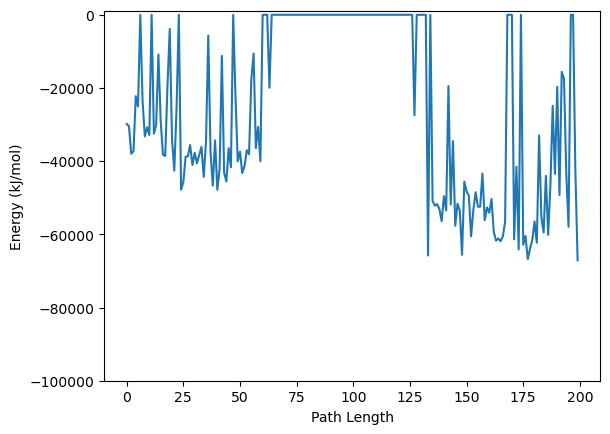

In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt


energies = np.clip(np.load("energies.npy"), -10**5, 10**0)
plt.figure()

plt.plot(energies)
plt.xlabel("Path Length")
plt.ylabel("Energy (kJ/mol)")
# plt.yscale("log")
plt.ylim(-10**5, 10**3)



In [1]:
import os
import torch
import mdtraj as md
import numpy as np
from tqdm import tqdm
from pathlib import Path
from datasets.dataset_utils_empty import Molecules, DEShawDataset, AtomSelection, to_angstrom, norm_stds
from models.graph_transformer import GraphTransformer
from evaluate.evaluators import TicEvaluator
from evaluate.evaluate_fastfolders import CLUSTER_ENDPOINTS
from evaluate.msm_utils import discretize_trajectory
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device(torch.cuda.current_device())
protein_name = "trp_cage"

gen_mode = "langevin" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = None # Append string to the experiment name"
append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
eval_folder = f"./saved_models/{protein_name}/main_eval_output_{gen_mode}{append_exp_name_str}"

# Load samples from the ground truth simulations to serve as training data
dataset = DEShawDataset(
    data_root="/data/sanjeevr/Reference_MD_Sims",
    molecule=Molecules[protein_name.upper()],
    simulation_id=0,
    atom_selection=AtomSelection.PROTEIN,
    return_bond_graph=False,
    transform=to_angstrom,
    align=False,
)


gt_traj = 10 * torch.tensor(dataset.traj.xyz)  # convert to angstroms
gt_traj -= gt_traj.mean(1, keepdims=True)  # center

n_atoms = gt_traj.shape[1]


/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/mdtraj/formats/pdb/pdbfile.py:206: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


In [5]:
# Save ground truth traj to ovito
from logging_utils import save_ovito_traj
topology = md.load("/data/sanjeevr/Reference_MD_Sims/2JOF/simulation_0/protein/2JOF-0-protein/2JOF-0-protein.pdb").topology
all_mol_traj = md.Trajectory(gt_traj[0:100000].numpy() / 10, topology=topology)
all_mol_traj.save_pdb(f"trp_cage_gt.pdb")

In [7]:
all_mol_traj = md.Trajectory(gt_traj[0].numpy() / 10, topology=topology)
all_mol_traj.save_pdb(f"trp_cage_folded.pdb")

Text(0, 0.5, 'SSD / Δθ')

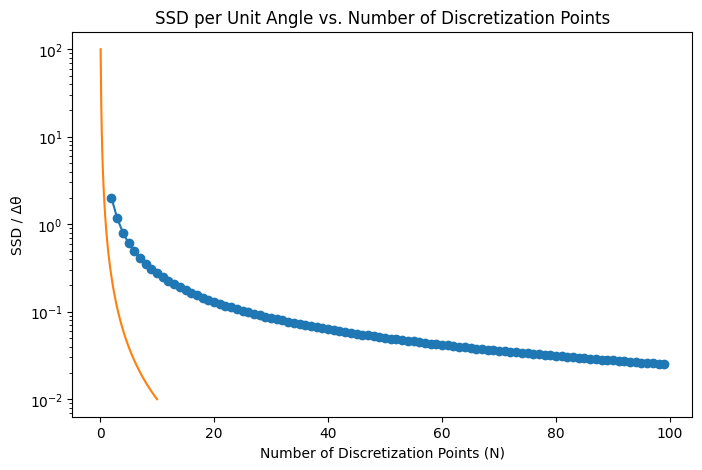

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Define the arc parameters
theta_start = 0
theta_end = np.pi / 2
radius = 1  # Unit circle

# Define a range of discretization points
N_values = np.arange(2, 100)  # From 2 points to 99 points

ssd_per_angle_values = []  # Store SSD / delta angle for each N

for N in N_values:
    # Generate N points along the arc
    theta = np.linspace(theta_start, theta_end, N)
    
    # Compute (x, y) coordinates
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    
    # Compute squared distances between consecutive points
    squared_distances = np.diff(x)**2 + np.diff(y)**2
    ssd = np.sum(squared_distances)
    
    # Compute delta theta
    # delta_theta = (theta_end - theta_start) / (N - 1)
    delta_theta = 1 #(theta_end - theta_start) / N
    
    # Compute SSD / delta_theta
    ssd_per_angle = ssd / delta_theta
    ssd_per_angle_values.append(ssd_per_angle)

# Plot SSD / delta angle as a function of N
plt.figure(figsize=(8, 5))
plt.plot(N_values, ssd_per_angle_values, marker='o', linestyle='-')
plt.xlabel("Number of Discretization Points (N)")
plt.ylabel("Sum of Squared Distances / Δθ")
plt.title("SSD per Unit Angle vs. Number of Discretization Points")

# make a plot of y = 1/x
x = np.linspace(0.1, 10, 100)
y = 1 / (x**2)
plt.yscale("log")
plt.plot(x, y)
plt.xlabel("Number of Discretization Points (N)")
plt.ylabel("SSD / Δθ")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import io
import base64
from PIL import Image  # For rotating the final frames

# --- 1) Simulate 1D Brownian motion ---
# np.random.seed(0)
n_steps = 60

# Cumulative sum of random steps
increments = np.random.normal(loc=0, scale=1, size=n_steps)
positions = np.cumsum(increments)
positions = np.insert(positions, 0, 0.0)  # Start at 0

# --- 2) Generate each frame, store in a list ---
frames = []
x = np.arange(len(positions))  # Standard left-to-right motion
y_min, y_max = positions.min(), positions.max()

for frame_idx in range(len(positions)):
    fig, ax = plt.subplots()
    plt.axis("off")  # Remove all borders and labels

    # Plot only points up to `frame_idx`
    ax.plot(x[:frame_idx+1], positions[:frame_idx+1], lw=2, color="blue")

    # Set consistent axis limits
    ax.set_xlim(0, len(positions) - 1)
    ax.set_ylim(y_min - 1, y_max + 1)

    # Render to NumPy array
    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)

    # Rotate the image 90 degrees counterclockwise
    rotated_image = Image.fromarray(image).rotate(90, expand=True)
    frames.append(np.array(rotated_image))

# --- 3) Save frames to an in-memory GIF ---
# gif_buffer = io.BytesIO()
# imageio.mimsave(gif_buffer, frames, format="GIF", fps=20)
# gif_buffer.seek(0)

# # --- 4) Encode GIF in base64 for inline display ---
# gif_base64 = base64.b64encode(gif_buffer.read()).decode("utf-8")
# gif_datauri = f"data:image/gif;base64,{gif_base64}"

# --- Save frames to a GIF file ---
gif_filename = "brownian_motion_up2.gif"  # Change the filename as needed
imageio.mimsave(gif_filename, frames, format="GIF", fps=30)

# print(f"GIF saved as {gif_filename}")


# print("GIF Data URI (copy/paste into a browser or <img> tag):")
# print(gif_datauri)


/tmp/ipykernel_355068/1082757313.py:35: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)


In [61]:
import torch
import re

def extract_bonds_from_mae(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    bond_section = False
    bonds = []

    for line in lines:
        line = line.strip()

        # Detect the start of the m_bond block
        if line.startswith("m_bond"):
            bond_section = True
            continue

        # Detect the end of the block
        if bond_section and line.startswith("}"):
            break

        # Skip the header inside the block (first few lines)
        if bond_section and ":::" in line:
            continue

        # Extract bond data
        if bond_section:
            parts = re.split(r'\s+', line)  # Split by whitespace
            if len(parts) >= 4:  # Ensure valid data row
                i_m_from, i_m_to = int(parts[1]), int(parts[2])
                bonds.append([i_m_from, i_m_to])

    # Convert to torch.Tensor
    bond_tensor = torch.tensor(bonds, dtype=torch.int64) - 1

    return bond_tensor


/tmp/ipykernel_3563130/312261828.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gt_traj = 10*torch.load(gt_traj_path)


Computing TIC features
Fitting TICA


FileNotFoundError: [Errno 2] No such file or directory: './saved_models/chignolin_all_atom/main_eval_output_langevin/TICA_chignolin_GT.png'

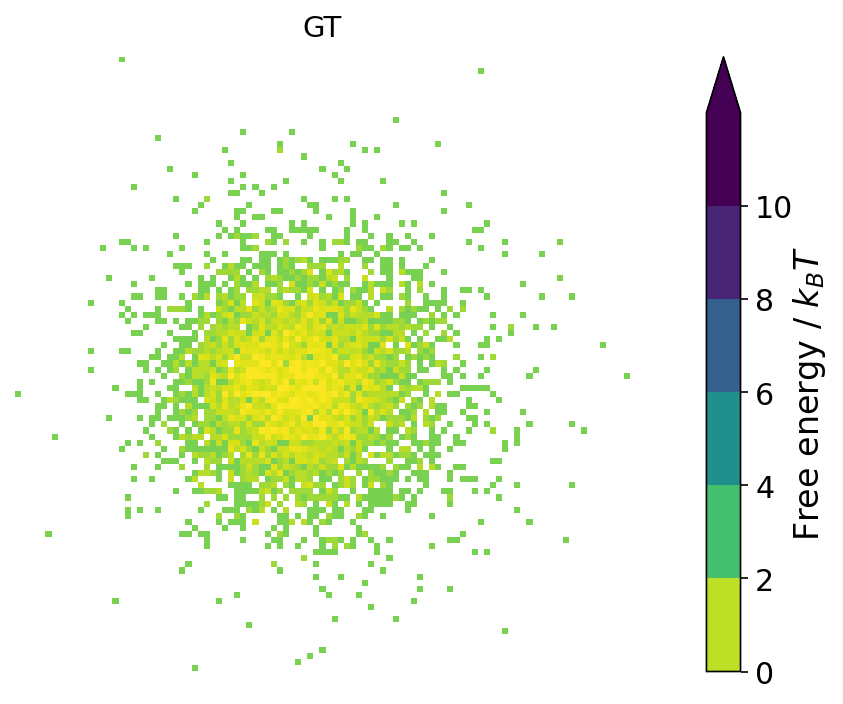

In [92]:
from datasets.dataset_utils_empty import AtomSelection, Molecules, to_angstrom, DEShawDataset
import mdtraj as md
import torch
import numpy as np
from rmsd import kabsch_rotate
from tqdm import tqdm

protein_name = "chignolin"
atom_selection = AtomSelection.PROTEIN

gen_mode = "langevin" # Mode of generation, "iid" or "langevin"
subsample = None # Give integer if only a random subset of the samples should be analyzed (if None, all samples are used)
append_exp_name = None # Append string to the experiment name"
append_exp_name_str = '_' + append_exp_name if append_exp_name else ''
all_atom_append = "_all_atom" if atom_selection == AtomSelection.PROTEIN else ""
eval_folder = f"./saved_models/{protein_name}{all_atom_append}/main_eval_output_{gen_mode}{append_exp_name_str}"

topology = md.load_topology(
        f"./datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-{atom_selection.value}.pdb"
    )

# Load samples from the ground truth simulations to serve as training data
gt_traj_path = os.path.join(
        "/data/sanjeevr/Reference_MD_Sims",
        Molecules[protein_name.upper()].value,
        f"gt_traj{all_atom_append}.pt",
    )
if os.path.exists(gt_traj_path):
    gt_traj = 10*torch.load(gt_traj_path)
else:
    print("Loading reference simulations")
    dataset = DEShawDataset(
        data_root="/data/sanjeevr/Reference_MD_Sims",
        molecule=Molecules[protein_name.upper()],
        simulation_id=0,
        atom_selection=atom_selection,
        return_bond_graph=False,
        transform=to_angstrom,
        align=False,
    )

    gt_traj = 10 * torch.tensor(dataset.traj.xyz)  # convert to angstroms
gt_traj -= gt_traj.mean(1, keepdims=True)  # center

gt_traj = gt_traj[::100]

tic_evaluator = TicEvaluator(
                val_data=None,
                mol_name=protein_name,
                eval_folder=eval_folder,
                data_folder="/data/sanjeevr/Reference_MD_Sims",
                atom_selection=atom_selection,
                folded_pdb_folder="datasets/folded_pdbs",
                bins=101,
                evalset="testset",
                gt_traj=gt_traj / 10,
            )

# This was code to figure out that there is some atom ordering discrepancy between the ground truth and the folded trajectory
folded = tic_evaluator.folded.xyz * 10
folded -= folded.mean(1, keepdims=True)

gt_traj = gt_traj[::100]
for i in tqdm(range(len(gt_traj))):
    gt_traj[i] = torch.tensor(kabsch_rotate(gt_traj[i].cpu(), folded[0]))
dists = np.linalg.norm(gt_traj - folded, axis=(-2, -1))
closest = gt_traj[dists.argmin()]

concat = np.concatenate([closest[None], folded], axis=0)

all_mol_traj = md.Trajectory(concat / 10, topology=topology)

all_mol_traj.save_pdb("test.pdb")

# Example usage
if atom_selection == AtomSelection.PROTEIN:
    pdb_bonds = torch.tensor([(bond[0].index, bond[1].index) for bond in topology.bonds])
    file_path = f"/data/sanjeevr/Reference_MD_Sims/{Molecules[protein_name.upper()].value}/simulation_0/protein/{Molecules[protein_name.upper()].value}-0-protein/{Molecules[protein_name.upper()].value}-0-protein.mae"
    mae_bonds = extract_bonds_from_mae(file_path)
    
save_ovito_traj(concat, "test.gsd", bonds=bonds)


In [94]:
import torch
import networkx as nx

def recover_permutation(bonds1, bonds2):
    """
    Recovers the permutation mapping node indices in the permuted graph (bonds1)
    to those in the original one (bonds2) using vf2pp_isomorphism from networkx.

    Args:
        bonds1 (torch.Tensor): Permuted graph edges of shape [N, 2]
        bonds2 (torch.Tensor): Original graph edges of shape [N, 2]

    Returns:
        dict or None: A dictionary mapping original node indices to permuted ones if an isomorphism exists, None otherwise.
    """
    # Create NetworkX graphs
    G1 = nx.Graph()
    G2 = nx.Graph()
    
    G1.add_edges_from(bonds1.tolist())
    G2.add_edges_from(bonds2.tolist())
    
    # Compute isomorphism
    iso_mapping = nx.vf2pp_isomorphism(G1, G2)
    
    if iso_mapping is None:
        return None
    
    # Convert mapping to tensor
    max_node = max(max(G1.nodes), max(G2.nodes)) + 1
    perm_tensor = torch.full((max_node,), -1, dtype=torch.long)
    
    for perm, orig in iso_mapping.items():
        perm_tensor[orig] = perm
    
    return perm_tensor
    
if atom_selection == AtomSelection.PROTEIN:
    pdb_bonds = torch.tensor([(bond[0].index, bond[1].index) for bond in topology.bonds])
    file_path = f"/data/sanjeevr/Reference_MD_Sims/{Molecules[protein_name.upper()].value}/simulation_0/protein/{Molecules[protein_name.upper()].value}-0-protein/{Molecules[protein_name.upper()].value}-0-protein.mae"
    mae_bonds = extract_bonds_from_mae(file_path)
mapping = recover_permutation(mae_bonds, pdb_bonds)
print(mapping)


tensor([  0,   4,  21,  22,   6,   9,  17,  10,  19,  12,  14,  15,   5,   7,
          8,  18,  11,  20,  13,  16,   1,   2,   3,  23,  25,  42,  43,  27,
         30,  31,  38,  33,  40,  35,  36,  24,  26,  28,  29,  32,  39,  34,
         41,  37,  44,  46,  54,  55,  48,  51,  52,  53,  45,  47,  49,  50,
         56,  60,  68,  69,  62,  65,  57,  61,  63,  64,  66,  67,  58,  59,
         70,  72,  83,  84,  74,  77,  80,  82,  81,  71,  73,  76,  75,  78,
         79,  85,  87,  97,  98,  89,  93,  91,  86,  88,  90,  92,  96,  94,
         95,  99, 101, 104, 105, 100, 102, 103, 106, 108, 118, 119, 110, 114,
        112, 107, 109, 111, 113, 117, 115, 116, 120, 122, 142, 143, 124, 127,
        128, 133, 132, 134, 130, 138, 136, 140, 121, 123, 126, 125, 129, 131,
        135, 139, 137, 141, 147, 149, 144, 151, 154, 162, 155, 164, 157, 159,
        160, 145, 146, 148, 150, 152, 153, 163, 156, 165, 158, 161])


In [79]:
torch.unique(bonds) 

tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
         42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
         56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
        112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
        126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
        140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153,
        154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165])

In [4]:
from datasets.dataset_utils_empty import AtomSelection
import os
import torch
import mdtraj as md
import numpy as np
from tqdm import tqdm
from pathlib import Path
from datasets.dataset_utils_empty import Molecules, AtomSelection, to_angstrom, norm_stds
from evaluate.evaluators import TicEvaluator
from evaluate.evaluate_fastfolders import CLUSTER_ENDPOINTS
from evaluate.msm_utils import discretize_trajectory
import matplotlib.pyplot as plt

###### INPUT ARGUMENTS ######
protein_name = "chignolin"
atom_selection = AtomSelection.A_CARBON # coarse graining level
device = torch.device("cuda:8")
mol = torch.randn((100, 10, 3)).to(device)### TODO: Load the protein positions here (shape should be [N_molecules, N_residues, 3])


start, end = CLUSTER_ENDPOINTS[protein_name]
# min-flux endpoints (not using for now)
cluster_endpoints_path = Path(
        os.path.join(
            "evaluate",
            "saved_references",
            f"saved_cluster_endpoints_{protein_name.upper()}.npy",
        )
    )

pdb_file = f"./datasets/folded_pdbs/{Molecules[protein_name.upper()].value}-0-{atom_selection.value}.pdb"

# Load cluster centers
cluster_centers_path = Path(
    os.path.join(
        "evaluate",
        "saved_references",
        f"saved_cluster_centers_{protein_name.upper()}.npy",
    )
)
cluster_coords = np.load(cluster_centers_path)

# Get TICA object
tic_evaluator = TicEvaluator(
    val_data=None,
    mol_name=protein_name,
    eval_folder=None,
    data_folder="datasets",
    atom_selection=atom_selection,
    folded_pdb_folder="datasets/folded_pdbs",
    bins=101,
    evalset="testset",
)

# assign samples to clusters between 0-19
cluster_assignments, transformed_samples = discretize_trajectory(
    mol.cpu(), tic_evaluator, cluster_coords
)

cluster_assignments = torch.tensor(cluster_assignments)

# get the start and end cluster assignments
is_start = cluster_assignments == start
is_end = cluster_assignments == end

/tmp/ipykernel_3961904/2489441452.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transition_path = torch.load(f"saved_models/{protein_name}/main_eval_output_om_interpo

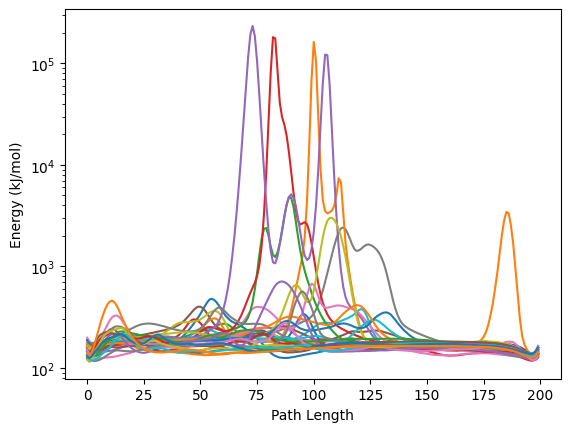

In [14]:
import torch
import numpy as np
from utils import TorchMD_CGProteinPriorForces
import matplotlib.pyplot as plt


protein_name = "bba"
exp_name = "test_initial_latent_time_250_hutch_minus_SGD_32paths"
num_paths = 32

protein_prior = TorchMD_CGProteinPriorForces(
                yaml_file="./dynamics/cg_prior_force_field.yaml",
                topology_file=f"./datasets/folded_pdbs/cg_{protein_name}.psf",
                device = torch.device(torch.cuda.current_device()),
            )
transition_path = torch.load(f"saved_models/{protein_name}/main_eval_output_om_interpolate_{exp_name}/sample-om_interpolate.pt")
n_atoms = transition_path.shape[-2]

transition_path = transition_path.to(torch.device(torch.cuda.current_device()))
energies = torch.vmap(protein_prior)(transition_path)[0]

energies = 4.814 * energies.reshape(num_paths, 200)
# plot all the path energies
plt.figure()
for i in range(num_paths):
    plt.plot((energies[i]).detach().cpu().numpy())
plt.xlabel("Path Length")
plt.axhline(y=0, color='r', linestyle='--')
plt.ylabel("Energy (kJ/mol)")
plt.yscale("log")


NameError: name 'plt' is not defined